In [1]:
from imolcraft.calculator import DihedralCalculator, load_g16scan
from imolcraft.io.rdkit import atoms2rdkit
from imolcraft.trainer.dmff_utils import  *
from imolcraft.trainer import DihedralTrainer
from imolcraft.trainer.loss import loss_energy
from ase.io import read
from functools import partial

import matplotlib.pyplot as plt
import copy

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.


In [2]:
pdbfile = "dmc.pdb"
atoms = read(pdbfile)
mol, mol2d, _ = atoms2rdkit(atoms)
calculator = DihedralCalculator(atoms, "dmc", directory="temp_directory")
calculator.scan_list

[[1, 0, 2, 8], [1, 0, 3, 4], [0, 2, 8, 9], [0, 3, 4, 5]]

In [3]:
# mol2d で [1, 0, 3, 4]のdihedralをハイライト
from rdkit.Chem import Draw
from rdkit.Chem import rdMolTransforms
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D

# H原子は表示しない
rdDepictor.Compute2DCoords(mol2d)
d = rdMolDraw2D.MolDraw2DCairo(500, 500)

#d.DrawMolecule(mol2d, highlightAtoms=[1, 0, 3, 4])でハイライトの色は薄め
highlight_atoms = [1, 0, 3, 4]
highlight_atom_colors = {idx: (1, 0.5, 0.5) for idx in highlight_atoms}
d.DrawMolecule(mol2d, highlightAtoms=highlight_atoms, highlightAtomColors=highlight_atom_colors)
d.FinishDrawing()

with open("dmc_dihedral.png", "wb") as f:
    f.write(d.GetDrawingText())

In [4]:
# # check dihedral atom index -> 1,0,2,8
# view(load_g16scan("dmc_dihed_0.log")[2])
# # check dihedral atom index -> 0,2,8,9
# view(load_g16scan("dmc_dihed_2.log")[2])

In [5]:
calculator.scan_list  = [calculator.scan_list[0] , calculator.scan_list[2]]
calculator.qm_calculators = [calculator.qm_calculators[0], calculator.qm_calculators[2]]
calculator.ff_calculators = [calculator.ff_calculators[0], calculator.ff_calculators[2]]
calculator.qm_scan = [calculator.qm_scan[0], calculator.qm_scan[2]]
calculator.ff_scan = [calculator.ff_scan[0], calculator.ff_scan[2]]

calculator.qm_scan[0]["angle_deg"], \
calculator.qm_scan[0]["energy_kjmol"], \
calculator.qm_scan[0]["atoms"], \
      = load_g16scan("dmc_dihed_0.log")

calculator.qm_scan[1]["angle_deg"], \
calculator.qm_scan[1]["energy_kjmol"], \
calculator.qm_scan[1]["atoms"], \
      = load_g16scan("dmc_dihed_2.log")

In [6]:
calculator.do_ffscan("dmc.xml", angles="QM", ini_geom="FF")
# calculator.do_ffscan("dmc1_best.xml", angles="QM", ini_geom="FF")

In [7]:
ff0_origin = copy.deepcopy(calculator.ff_scan[0]["energy_kjmol"])
ff1_origin = copy.deepcopy(calculator.ff_scan[1]["energy_kjmol"])

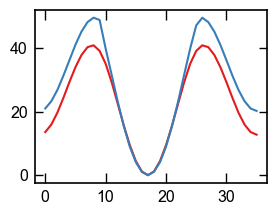

In [8]:
plt.plot(calculator.qm_scan[0]["energy_kjmol"])
plt.plot(calculator.ff_scan[0]["energy_kjmol"])

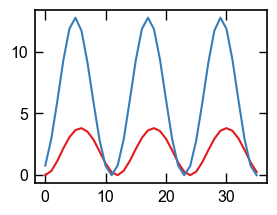

In [9]:
plt.plot(calculator.qm_scan[1]["energy_kjmol"])
plt.plot(calculator.ff_scan[1]["energy_kjmol"])

In [10]:
len(calculator.qm_scan)

2

In [20]:
lossfn = partial(loss_energy, weight_scheme="uniform", zeropoint="qmmin")

In [21]:
tr = DihedralTrainer(
    ffxml="dmc.xml",
    pdbfile=pdbfile,
    calculator=calculator,
    loss_fn=lossfn,
    opt_fftypes=["PeriodicTorsionForce/proper_k"],
    relax_steps=1,
    lr=0.5,
    clip=0.5
)

In [22]:
tr.setup()

In [23]:
tr.fit(steps=10)

grad obtained.... Memory Usage: 1238.17 MB
grad modify.... Memory Usage: 1238.17 MB
update finished.... Memory Usage: 1238.17 MB
Epoch 0, Loss: 15.397280354950894, Memory Usage: 1247.20 MB
Loss:  15.397280354950894
Best Loss:  15.397280354950894 at epoch  0
Epoch 0 completed in 17.44 seconds.
----
grad obtained.... Memory Usage: 1268.80 MB
grad modify.... Memory Usage: 1268.80 MB
update finished.... Memory Usage: 1268.80 MB
Loss:  5.73877012532274
Best Loss:  5.73877012532274 at epoch  1
Epoch 1 completed in 17.01 seconds.
----
grad obtained.... Memory Usage: 1278.48 MB
grad modify.... Memory Usage: 1278.48 MB
update finished.... Memory Usage: 1278.48 MB
Loss:  1.6665695641399598
Best Loss:  1.6665695641399598 at epoch  2
Epoch 2 completed in 17.04 seconds.
----
grad obtained.... Memory Usage: 1293.22 MB
grad modify.... Memory Usage: 1293.22 MB
update finished.... Memory Usage: 1293.22 MB
Loss:  0.3367620719302515
Best Loss:  0.3367620719302515 at epoch  3
Epoch 3 completed in 16.98 se

In [24]:
tr.relax_steps = 100
tr.fit(steps=1000)

grad obtained.... Memory Usage: 1409.02 MB
grad modify.... Memory Usage: 1409.02 MB
update finished.... Memory Usage: 1409.02 MB
Loss:  0.59221047590244
Best Loss:  0.3367620719302515 at epoch  3
Epoch 11 completed in 0.02 seconds.
----
grad obtained.... Memory Usage: 1409.02 MB
grad modify.... Memory Usage: 1409.02 MB
update finished.... Memory Usage: 1409.02 MB
Loss:  0.3153368548530456
Best Loss:  0.3153368548530456 at epoch  12
Epoch 12 completed in 0.02 seconds.
----
grad obtained.... Memory Usage: 1409.02 MB
grad modify.... Memory Usage: 1409.02 MB
update finished.... Memory Usage: 1409.02 MB
Loss:  0.42123830845737253
Best Loss:  0.3153368548530456 at epoch  12
Epoch 13 completed in 0.01 seconds.
----
grad obtained.... Memory Usage: 1409.02 MB
grad modify.... Memory Usage: 1409.02 MB
update finished.... Memory Usage: 1409.02 MB
Loss:  0.7682638628182641
Best Loss:  0.3153368548530456 at epoch  12
Epoch 14 completed in 0.01 seconds.
----
grad obtained.... Memory Usage: 1409.02 MB

KeyboardInterrupt: 

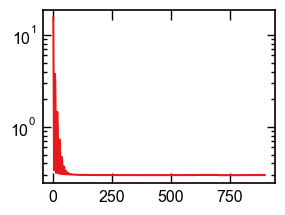

In [25]:
# plt.xscale("log")
plt.yscale("log")
plt.plot(tr.epochs, tr.losses)

In [26]:
# view(calculator.ff_scan[0]["atoms"])

In [27]:
calculator.do_ffscan("dmc1_best.xml", angles="QM", ini_geom="FF")

Text(0, 0.5, 'Energy (kJ/mol)')

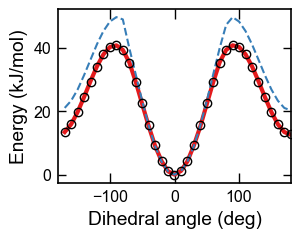

In [30]:
plt.xlim(-180,180)
plt.plot(np.array(calculator.ff_scan[0]["angle_deg"]), calculator.ff_scan[0]["energy_kjmol"], linewidth=3)
plt.plot(calculator.ff_scan[0]["angle_deg"], ff0_origin, linestyle='--')
plt.plot(calculator.qm_scan[0]["angle_deg"], calculator.qm_scan[0]["energy_kjmol"], marker="o", linestyle='None', color="black", fillstyle='none') # 白抜き
plt.xlabel("Dihedral angle (deg)")
plt.ylabel("Energy (kJ/mol)")
# plt.plot(np.array(tr.calculator.ff_scan[0]["angle_deg"])-180, tr.calculator.ff_scan[0]["energy_kjmol"], marker="o")
# plt.plot(np.array(tr.calculator.ff_scan[0]["angle_deg"])+180, tr.calculator.ff_scan[0]["energy_kjmol"], marker="o")

Text(0, 0.5, 'Energy (kJ/mol)')

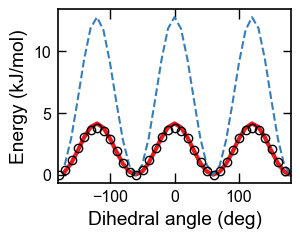

In [31]:
plt.xlim(-180,180)
plt.plot(np.array(calculator.ff_scan[1]["angle_deg"]), calculator.ff_scan[1]["energy_kjmol"], linewidth=3)
plt.plot(calculator.ff_scan[1]["angle_deg"], ff1_origin, linestyle='--')
plt.plot(calculator.qm_scan[1]["angle_deg"], calculator.qm_scan[1]["energy_kjmol"], marker="o", linestyle='None', color="black", fillstyle='none') # 白抜き
plt.xlabel("Dihedral angle (deg)")
plt.ylabel("Energy (kJ/mol)")
# plt.plot(np.array(tr.calculator.ff_scan[0]["angle_deg"])-180, tr.calculator.ff_scan[0]["energy_kjmol"], marker="o")
# plt.plot(np.array(tr.calculator.ff_scan[0]["angle_deg"])+180, tr.calculator.ff_scan[0]["energy_kjmol"], marker="o")